***Q2: Sentiment Classification Using RNN***

Task: Sentiment analysis determines if a given text expresses a positive or negative emotion. You will train an LSTM-based sentiment classifier using the IMDB dataset.

- Load the IMDB sentiment dataset (tensorflow.keras.datasets.imdb).
- Preprocess the text data by tokenization and padding sequences.
- Train an LSTM-based model to classify reviews as positive or negative.
- Generate a confusion matrix and classification report (accuracy, precision, recall, F1-score).
- Interpret why precision-recall tradeoff is important in sentiment classification.

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [4]:
# load dataset
VOCAB_SIZE = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

print("\nFirst review:")
print(x_train[0])

print("\nFirst label:")
print(y_train[0])

Training samples: 25000
Testing samples: 25000

First review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32

In [8]:
# decoding the review 
word_index = imdb.get_word_index()

reverse_word_index = {
    index + 3: word
    for word, index in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

decoded_review = " ".join(
    reverse_word_index.get(i, "?")
    for i in x_train[0]
)

print(decoded_review)
print("\nSentiment:", "Positive" if y_train[0] == 1 else "Negative")

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wha

In [9]:
# padding the sequence, neural networks train more efficiently when examples in a batch have the same sequence length

MAX_LENGTH = 250

x_train = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

In [10]:
print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (25000, 250)
Testing shape: (25000, 250)


In [11]:
# lstm model 

EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    LSTM(LSTM_UNITS),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [12]:
model.build(input_shape=(None, MAX_LENGTH))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
# train the model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 81ms/step - accuracy: 0.7634 - loss: 0.4890 - val_accuracy: 0.7734 - val_loss: 0.4729
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.8770 - loss: 0.3126 - val_accuracy: 0.8644 - val_loss: 0.3216
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.9163 - loss: 0.2260 - val_accuracy: 0.8590 - val_loss: 0.3360
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.9410 - loss: 0.1649 - val_accuracy: 0.8700 - val_loss: 0.3669
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step - accuracy: 0.9510 - loss: 0.1404 - val_accuracy: 0.8648 - val_loss: 0.3725


In [15]:
# evaluation on test data

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8459 - loss: 0.4147
Test Loss: 0.4146520793437958
Test Accuracy: 0.8458799719810486


In [16]:
# confusion matrix

y_prob = model.predict(x_test)
y_pred = (y_prob >= 0.5).astype("int32").flatten()
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
[[10749  1751]
 [ 2102 10398]]


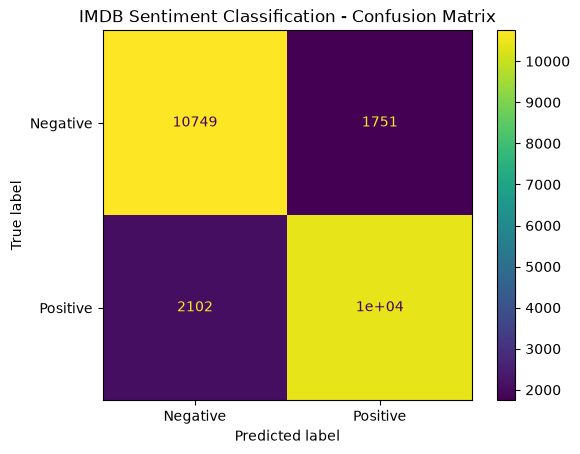

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("IMDB Sentiment Classification - Confusion Matrix")
plt.show()

In [18]:
# classification report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.84      0.86      0.85     12500
    Positive       0.86      0.83      0.84     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



***Precision-Recall Tradeoff***
The precision-recall tradeoff is crucial in sentiment analysis depending on business applications:

- ***High Precision***: Minimizes false positives (predicting positive when it's actually negative). This is vital if you are automatically refunding customers based on positive reviews or deploying automated brand responses where a misclassified negative review could spark a PR crisis.

- ***High Recall***: Minimizes false negatives (missing actual positive/negative reviews). This is essential in customer feedback monitoring where you want to catch every single angry customer complaint so support teams can intervene.

- ***Decision Threshold***: Adjusting the classification threshold (default 0.5) allows you to shift the balance between precision and recall depending on whether false alarms or missed detections are more costly.